# A linearized forward model for paired (non-interlaced) light-off / light-on scans

Notebook 05 develops the *linearized forward model* for excitation-induced phase
reconstruction on an **interlaced** acquisition: light-off and light-on frames sit at
disjoint, alternating (checkerboard) scan positions, so no position ever has both. That
forces an extra approximation — the light-off wave at every light-on position has to be
*reconstructed from elsewhere and forward-simulated in*, i.e. the off-state is
extrapolated into positions where it was never measured.

This notebook drops the interlacing. The acquisition here is **two full datasets
captured one on top of the other**: the same scan grid is recorded twice, once with the
excitation off and once with it on, so every position $\mathbf{R}$ has both
$I_{off}(\mathbf{k};\mathbf{R})$ and $I_{on}(\mathbf{k};\mathbf{R})$. Nothing has to be
filled in, and the linearization can be applied directly to a genuine *paired
difference*.

Three things change relative to notebook 05, and they are what this notebook is about:

1. **$\varphi_{off}$ is reconstructed from the whole scan.** An ordinary single-channel
   `ObjectPixelated` reconstruction on all $N$ native positions — no `ObjectMultiplexed`,
   no `patches_mask` channel routing, twice the frames of a de-interlaced channel.
2. **$\psi_{off}$ is interpolated, not extrapolated.** It is evaluated at exactly the
   positions the reconstruction was driven by.
3. **The zeroth-order baseline can be *measured*.** In the linear model
   $I_{on}\approx I_{off} + \Delta I$, the term $I_{off}$ can be the real light-off frame
   recorded at that same position, instead of the reconstruction's own $|\Psi_{off}|^2$.
   The fit residual then becomes a true paired difference, in which systematic error
   shared by the two states cancels instead of leaking into $\Delta\varphi$.

The pipeline lives in `paired_linearized.py` (a sibling of `method_wrappers.py`, whose
`linearized_model` is the interlaced counterpart); this notebook runs it in the same
three steps of increasing realism as notebook 05 — ground-truth $\varphi_{off}$, then a
real reconstruction, then a dose sweep.

## The math

### 1. Exact forward model

For a thin object with phase $\varphi(\mathbf{r})$ and a probe $P$ placed at scan
position $\mathbf{R}$, the exit wave and the recorded intensity are

$$\psi(\mathbf{r};\mathbf{R}) = P(\mathbf{r}-\mathbf{R})\,e^{i\varphi(\mathbf{r})},
\qquad
I(\mathbf{k};\mathbf{R}) = \bigl|\mathcal{F}\{\psi(\cdot\,;\mathbf{R})\}(\mathbf{k})\bigr|^2 .$$

Write $\varphi_{on} = \varphi_{off} + \Delta\varphi$, where $\Delta\varphi$ is the
excitation-induced phase we want. Then exactly

$$\psi_{on}(\mathbf{r};\mathbf{R}) = \psi_{off}(\mathbf{r};\mathbf{R})\,
e^{i\Delta\varphi(\mathbf{r})}.$$

### 2. Linearization in $\Delta\varphi$

The excitation phase is small ($|\Delta\varphi|\ll 1$; for this phantom
$\max|\Delta\varphi|\approx 0.02$ rad), so

$$e^{i\Delta\varphi} = 1 + i\Delta\varphi + \mathcal{O}(\Delta\varphi^2)
\quad\Longrightarrow\quad
\psi_{on} \approx \psi_{off} + i\,\psi_{off}\Delta\varphi .$$

Fourier transforming, with $\Psi_{off}=\mathcal{F}\{\psi_{off}\}$,

$$\Psi_{on} \approx \Psi_{off} + i\,\mathcal{F}\{\psi_{off}\Delta\varphi\},$$

and taking the squared modulus, dropping the $\mathcal{O}(\Delta\varphi^2)$ term,

$$\boxed{\;
I_{on} \;\approx\; \underbrace{|\Psi_{off}|^2}_{I_{off}}
\;\underbrace{-\,2\,\mathrm{Im}\!\left[\Psi_{off}^{*}\,
\mathcal{F}\{\psi_{off}\Delta\varphi\}\right]}_{\displaystyle \Delta I[\Delta\varphi]}\;}$$

$\Delta I$ is a **linear** operator acting on $\Delta\varphi$ — call it
$\mathcal{L}\Delta\varphi$. That is the whole point: the map from the unknown to the
prediction contains no products of unknowns.

### 3. What the interlaced case has to approximate, and this one does not

The zeroth-order term $I_{off}$ is the light-off intensity **at the light-on position**.

* *Interlaced (notebook 05):* no such frame exists. It must be replaced by the
  reconstruction's own $|\Psi_{off}^{\text{recon}}|^2$, an extrapolation into an
  unmeasured position. Any error in that model — imperfect probe, unconverged object,
  residual raster-grid artifact — enters the residual with nothing to cancel it, and the
  fit absorbs it into $\Delta\varphi$.
* *Paired (this notebook):* the frame exists. Using it, the residual becomes

$$r = \bigl(I_{off}^{\text{meas}} + \mathcal{L}\Delta\varphi\bigr) - I_{on}^{\text{meas}}
 \;=\; \mathcal{L}\Delta\varphi - \underbrace{\bigl(I_{on}^{\text{meas}} -
 I_{off}^{\text{meas}}\bigr)}_{\text{measured difference}},$$

  i.e. $\Delta\varphi$ is fit **directly to the measured intensity difference**. Every
  systematic error common to the two states (probe error, detector gain, sample drift in
  the model, unconverged $\varphi_{off}$) subtracts out of the data side of the equation.
  The reconstruction is still needed — but only for the *operator* $\mathcal{L}$
  ($\psi_{off}$ and $\Psi_{off}$), never for the baseline. Both options are implemented
  (`baseline="measured"` / `"simulated"`) and compared throughout, since the trade is not
  free: differencing two noisy frames adds their variances, whereas the simulated
  baseline is smooth.

### 4. The fit is convex

With $\mathcal{L}$ linear, the objective

$$\Delta\varphi^{*} = \operatorname*{argmin}_{\Delta\varphi}
\sum_{\mathbf{R},\mathbf{k}} w_{\mathbf{R},\mathbf{k}}
\Bigl(\mathcal{L}\Delta\varphi - \bigl(I_{on}^{\text{meas}}-I_{off}\bigr)\Bigr)^2
\;+\; \lambda \sum_{\mathbf{r}} \sqrt{|\nabla\Delta\varphi|^2 + \epsilon^2}$$

is a **convex quadratic plus a convex penalty**, with a single minimum:

* the fixed weights $w = 1/I_{off}$ (inverse-variance weighting for Poisson counts —
  Gauss-Newton on the Poisson negative log-likelihood) are constants, so weighting does
  not break the quadratic form;
* the Charbonnier term $\sqrt{|\nabla\Delta\varphi|^2+\epsilon^2}$ is the Euclidean norm
  of an affine map of $\Delta\varphi$, hence convex, and smooth thanks to $\epsilon$.

So every fit below is solved full-batch with `torch.optim.LBFGS` (quasi-Newton +
strong-Wolfe line search): no learning rate to tune, no stochastic-gradient noise, a
handful of outer iterations.

$\Delta\varphi$ is optimized as a zero-mean field — a constant phase offset is invisible
to intensity-only measurements, so it is not identifiable and is simply projected out.

In [1]:
import pickle
import gc
import os

import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

from abtem.waves import Probe
from abtem.core.energy import energy2sigma
from abtem.potentials.iam import PotentialArray
from abtem import PixelatedDetector
from abtem.scan import GridScan

import paired_linearized as pl

ACC_VOLTAGE     = 60e3  # eV
PROBE_SEMIANGLE = 30    # mrad
PROBE_DEFOCUS   = 0     # Angstrom
SCAN_STEP_SIZE  = 0.2   # Angstrom -- here the native step; there is no interlacing to halve

sigma = float(energy2sigma(ACC_VOLTAGE))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

The phantom is the same simulated bilayer-defect pair used in notebooks 04 and 05, so
every number here is directly comparable to notebook 05's interlaced results.

max|gt_delta_phi| = 0.0211 rad


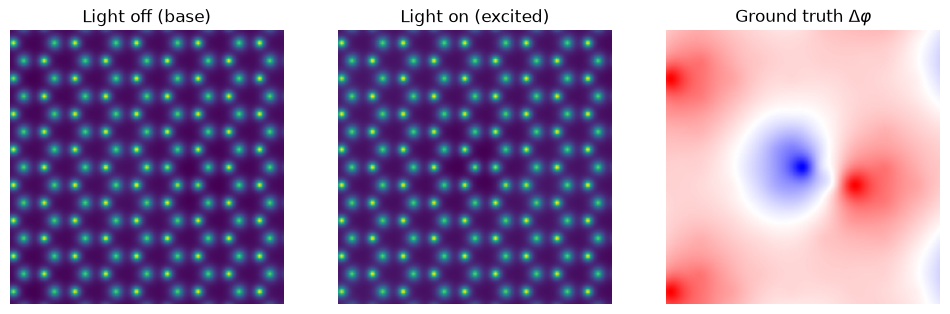

In [2]:
with open('bcenters_base_excited_phases_wide_fov.pkl', 'rb') as f:
    data = pickle.load(f)

base_phase = data['base'][25:-25, 25:-25]
excited_phase = data['excited'][25:-25, 25:-25]
x = data['x'][25:-25]
y = data['y'][25:-25]

dx = x[1] - x[0]
dy = y[1] - y[0]
gt_delta_phi = (excited_phase - base_phase).astype(np.float32)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(base_phase);     axs[0].set_title('Light off (base)')
axs[1].imshow(excited_phase);  axs[1].set_title('Light on (excited)')
axs[2].imshow(gt_delta_phi, cmap='bwr'); axs[2].set_title(r'Ground truth $\Delta\varphi$')
for ax in axs:
    ax.axis('off')
print(f'max|gt_delta_phi| = {np.abs(gt_delta_phi).max():.4f} rad')

## Simulate the paired 4D-STEM acquisition

A single-slice (thin-object) potential is built from each phase map and scanned with a
30 mrad, 60 keV probe at 0.2 Å steps. Both the light-off and the light-on dataset are
simulated on the **same** scan grid — that *is* the acquisition here, not an
intermediate product: `I_off_full` and `I_on_full` are the two datasets captured one on
top of the other. (Notebook 05 simulates exactly the same two arrays and then throws
half of each away to build its checkerboard `merged_scan`; the cache file is shared, so
no resimulation is needed.)

The cache exists because abtem's multislice simulation is not bit-exact run-to-run (GPU
FFT reduction order is not deterministic), and at marginal doses that $\sim10^{-7}$
jitter can flip a Poisson count and change an outcome. Delete `sim_cache_wide_fov.pkl`
to force a fresh simulation.

In [3]:
def make_potential(phase_image):
    V = (phase_image / sigma)[np.newaxis, :, :].astype(np.float32)
    return PotentialArray(array=V, slice_thickness=1, sampling=(dx, dy))


potential_off = make_potential(base_phase)
potential_on = make_potential(excited_phase)

probe = Probe(energy=ACC_VOLTAGE, semiangle_cutoff=PROBE_SEMIANGLE, defocus=PROBE_DEFOCUS)
probe.match_grid(potential_off)

scan = GridScan(
    start=(0.0, 0.0),
    end=potential_off.extent,
    potential=potential_off,
    sampling=SCAN_STEP_SIZE,
    endpoint=True,
)
positions = scan.get_positions()  # (nx_scan, ny_scan, 2), Angstrom
detector = PixelatedDetector(max_angle='valid')

_sim_cache_path = 'sim_cache_wide_fov.pkl'
if os.path.exists(_sim_cache_path):
    with open(_sim_cache_path, 'rb') as f:
        I_off_full, I_on_full = pickle.load(f)
else:
    base_meas = probe.scan(potential_off, scan=scan, detectors=detector)
    base_meas.compute()
    excited_meas = probe.scan(potential_on, scan=scan, detectors=detector)
    excited_meas.compute()
    I_off_full = np.asarray(base_meas.array)
    I_on_full = np.asarray(excited_meas.array)
    with open(_sim_cache_path, 'wb') as f:
        pickle.dump((I_off_full, I_on_full), f)

nx_scan, ny_scan = I_off_full.shape[:2]
n_pos = nx_scan * ny_scan
print(f'{I_off_full.shape} -- {n_pos} scan positions, each with BOTH an off and an on frame')
print(f'(notebook 05\'s interlaced scan uses {n_pos // 2} off frames and {n_pos // 2} on frames)')

(98, 98, 95, 95) -- 9604 scan positions, each with BOTH an off and an on frame
(notebook 05's interlaced scan uses 4802 off frames and 4802 on frames)


The measured difference $I_{on}-I_{off}$ is the quantity the paired fit works with
directly. It is worth looking at once: it is tiny relative to $I_{off}$ itself, which is
exactly why the first-order expansion is valid — and also why shot noise eats it first.

max|I_on - I_off| / max(I_off) = 1.83e-02


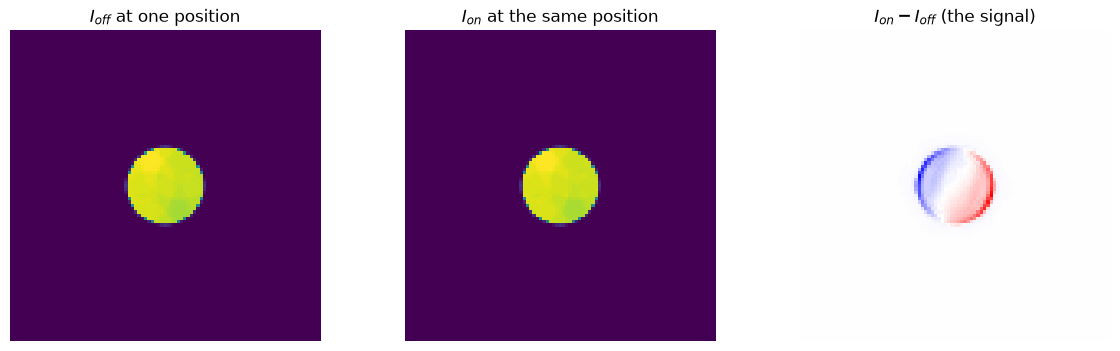

In [4]:
diff_full = I_on_full - I_off_full
rel = np.abs(diff_full).max() / I_off_full.max()
print(f'max|I_on - I_off| / max(I_off) = {rel:.2e}')

i0, j0 = nx_scan // 2, ny_scan // 2
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
axs[0].imshow(I_off_full[i0, j0]); axs[0].set_title(r'$I_{off}$ at one position')
axs[1].imshow(I_on_full[i0, j0]);  axs[1].set_title(r'$I_{on}$ at the same position')
m = np.abs(diff_full[i0, j0]).max()
axs[2].imshow(diff_full[i0, j0], cmap='bwr', vmin=-m, vmax=m)
axs[2].set_title(r'$I_{on}-I_{off}$ (the signal)')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

## Step 1 — the ceiling: linearized fit with the known (simulated) $\varphi_{off}$

Here $\psi_{off}(\mathbf{r};\mathbf{R}) = P(\mathbf{r}-\mathbf{R})\,e^{i\varphi_{off}(\mathbf{r})}$
is built directly from the known `base_phase` and an ideal `abtem` probe, at **every**
scan position (not half of them, as in the interlaced case). This is a cheat no real
experiment can perform; it establishes how well the linear fit can possibly do when the
operator $\mathcal{L}$ is exact.

### Fast forward model for $\psi_{off}$

Rather than re-running multislice (which returns only intensities), the free-space probe
is shifted to each scan position with `probe.build`, multiplied by the known light-off
transmission function, and FFT-cropped to the same "valid" detector window. For a single
thin slice this is mathematically identical to the `probe.scan` forward model — checked
below against the true simulated intensities before it is trusted.

In [5]:
T_off = torch.from_numpy(np.exp(1j * base_phase).astype(np.complex64)).to(device)
ny, nx = base_phase.shape
ndet = I_off_full.shape[-1]
cy, cx = ny // 2, nx // 2
half = ndet // 2


def psi_off_and_Psi_off(scan_positions, chunk=1000):
    psi_list, Psi_list = [], []
    for start in range(0, len(scan_positions), chunk):
        batch = scan_positions[start:start + chunk]
        w = probe.build(scan=batch)
        w.compute()
        free_probe = torch.from_numpy(np.asarray(w.array).astype(np.complex64)).to(device)
        psi = free_probe * T_off[None]
        Psi_full = torch.fft.fftshift(torch.fft.fft2(psi), dim=(-2, -1))
        Psi = Psi_full[..., cy - half:cy + half + 1, cx - half:cx + half + 1]
        psi_list.append(psi)
        Psi_list.append(Psi)
    return torch.cat(psi_list, dim=0), torch.cat(Psi_list, dim=0)


check_positions = positions[::40, ::40].reshape(-1, 2)
psi_check, Psi_check = psi_off_and_Psi_off(check_positions)
I_check_fast = (Psi_check.abs() ** 2).cpu().numpy()

check_ix, check_iy = np.meshgrid(np.arange(0, nx_scan, 40), np.arange(0, ny_scan, 40), indexing='ij')
I_check_true = I_off_full[check_ix.ravel(), check_iy.ravel()]

rel_err = np.abs(I_check_fast - I_check_true).max() / I_check_true.max()
corr_check = np.corrcoef(I_check_fast.ravel(), I_check_true.ravel())[0, 1]
print(f'fast forward-model vs. true multislice intensities: max rel. err={rel_err:.2e}, corr={corr_check:.10f}')

del psi_check, Psi_check
gc.collect(); torch.cuda.empty_cache()

fast forward-model vs. true multislice intensities: max rel. err=1.32e-06, corr=1.0000000000


### Build $\psi_{off}$ / $\Psi_{off}$ at every scan position

These depend only on the light-off state and are reused by both variants of the fit
below.

In [6]:
all_positions = positions.reshape(-1, 2)
psi_off_real, Psi_off_k = psi_off_and_Psi_off(all_positions)
print(f'psi_off: {tuple(psi_off_real.shape)}   Psi_off: {tuple(Psi_off_k.shape)}')

I_off_meas = torch.from_numpy(I_off_full.reshape(-1, ndet, ndet).astype(np.float32)).to(device)
I_on_meas = torch.from_numpy(I_on_full.reshape(-1, ndet, ndet).astype(np.float32)).to(device)

# one shared normalization so every intensity is O(1) and LBFGS' steps behave
norm_const = I_off_meas.mean()
I_off_meas_n = I_off_meas / norm_const
I_off_sim_n = (Psi_off_k.abs() ** 2) / norm_const
I_on_n = I_on_meas / norm_const
Psi_off_k_n = Psi_off_k / torch.sqrt(norm_const)

tasks:  14%|#4        | 1/7 [00:00<00:03,  1.74it/s]

tasks:  14%|#4        | 1/7 [00:00<00:03,  1.98it/s]

tasks:  43%|####2     | 3/7 [00:00<00:01,  3.63it/s]

tasks:  14%|#4        | 1/7 [00:00<00:03,  1.91it/s]

tasks:  14%|#4        | 1/7 [00:00<00:03,  1.70it/s]

...

tasks:  14%|#4        | 1/7 [00:00<00:03,  1.85it/s]

tasks:  14%|#4        | 1/7 [00:00<00:03,  1.88it/s]

tasks:  43%|####2     | 3/7 [00:00<00:01,  3.47it/s]

tasks:  60%|######    | 3/5 [00:00<00:00,  3.30it/s]

psi_off: (9604, 201, 201)   Psi_off: (9604, 95, 95)


### The fit

$$\Delta I[\Delta\varphi] = -2\,\mathrm{Im}\!\left[\Psi_{off}^{*}\,
\mathcal{F}\{\psi_{off}\Delta\varphi\}\right],\qquad
\min_{\Delta\varphi}\ \bigl\langle\, w\,\bigl(I_{off}+\Delta I[\Delta\varphi]-I_{on}^{\text{meas}}
\bigr)^2 \bigr\rangle$$

run twice, with the two choices of the baseline $I_{off}$:

* `measured` — the recorded light-off frame at the same position (only possible because
  the scans are paired);
* `simulated` — $|\Psi_{off}|^2$ from the forward model, which is all the interlaced
  acquisition of notebook 05 can use.

Weights $w=1/I_{off}^{\text{sim}}$ always come from the *smooth* simulated intensity, even
in the `measured` variant: the weights must not be fed their own noise.

The loss trace is recorded at every LBFGS evaluation and plotted — a smooth, monotone
descent to a single plateau is what a correctly-solved convex problem looks like, and is
worth checking rather than assuming.

Step 1, baseline=measured :  NRMSE = 0.246   correlation = 0.997   (39 closure evaluations)


Step 1, baseline=simulated:  NRMSE = 0.246   correlation = 0.997   (35 closure evaluations)


Text(0.5, 1.0, 'Step 1 loss traces — smooth monotone descent, as a convex problem should give')

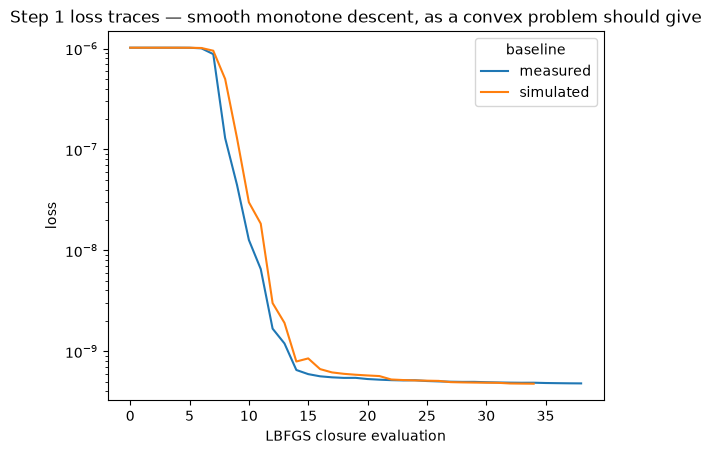

In [7]:
def forward_delta_I(dphi):
    pert = psi_off_real * dphi[None]
    Pert_full = torch.fft.fftshift(torch.fft.fft2(pert), dim=(-2, -1))
    Pert_k = Pert_full[..., cy - half:cy + half + 1, cx - half:cx + half + 1] / torch.sqrt(norm_const)
    return -2.0 * torch.imag(torch.conj(Psi_off_k_n) * Pert_k)


poisson_weight = 1.0 / (I_off_sim_n + 0.2 * I_off_sim_n.mean())
poisson_weight = torch.clamp(poisson_weight, max=10.0 / I_off_sim_n.mean())
poisson_weight = poisson_weight / poisson_weight.mean()


def fit_step1(baseline):
    I_base = I_off_meas_n if baseline == 'measured' else I_off_sim_n
    dphi_raw = torch.zeros((ny, nx), dtype=torch.float32, device=device, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [dphi_raw], lr=1.0, max_iter=100, tolerance_grad=1e-10,
        tolerance_change=1e-12, line_search_fn='strong_wolfe',
    )
    history = []

    def closure():
        optimizer.zero_grad()
        dphi = dphi_raw - dphi_raw.mean()   # constant offset is unobservable -> project out
        loss = torch.mean(poisson_weight * (I_base + forward_delta_I(dphi) - I_on_n) ** 2)
        loss.backward()
        history.append(loss.item())
        return loss

    optimizer.step(closure)
    return (dphi_raw - dphi_raw.mean()).detach().cpu().numpy(), history


step1 = {}
for baseline in ['measured', 'simulated']:
    recon, history = fit_step1(baseline)
    nrmse = np.sqrt(np.sum((recon - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
    corr = np.corrcoef(recon.ravel(), gt_delta_phi.ravel())[0, 1]
    step1[baseline] = dict(recon=recon, history=history, nrmse=nrmse, corr=corr)
    print(f'Step 1, baseline={baseline:9s}:  NRMSE = {nrmse:.3f}   correlation = {corr:.3f}   '
          f'({len(history)} closure evaluations)')

for baseline, r in step1.items():
    plt.plot(r['history'], label=baseline)
plt.yscale('log'); plt.xlabel('LBFGS closure evaluation'); plt.ylabel('loss')
plt.legend(title='baseline')
plt.title('Step 1 loss traces — smooth monotone descent, as a convex problem should give')

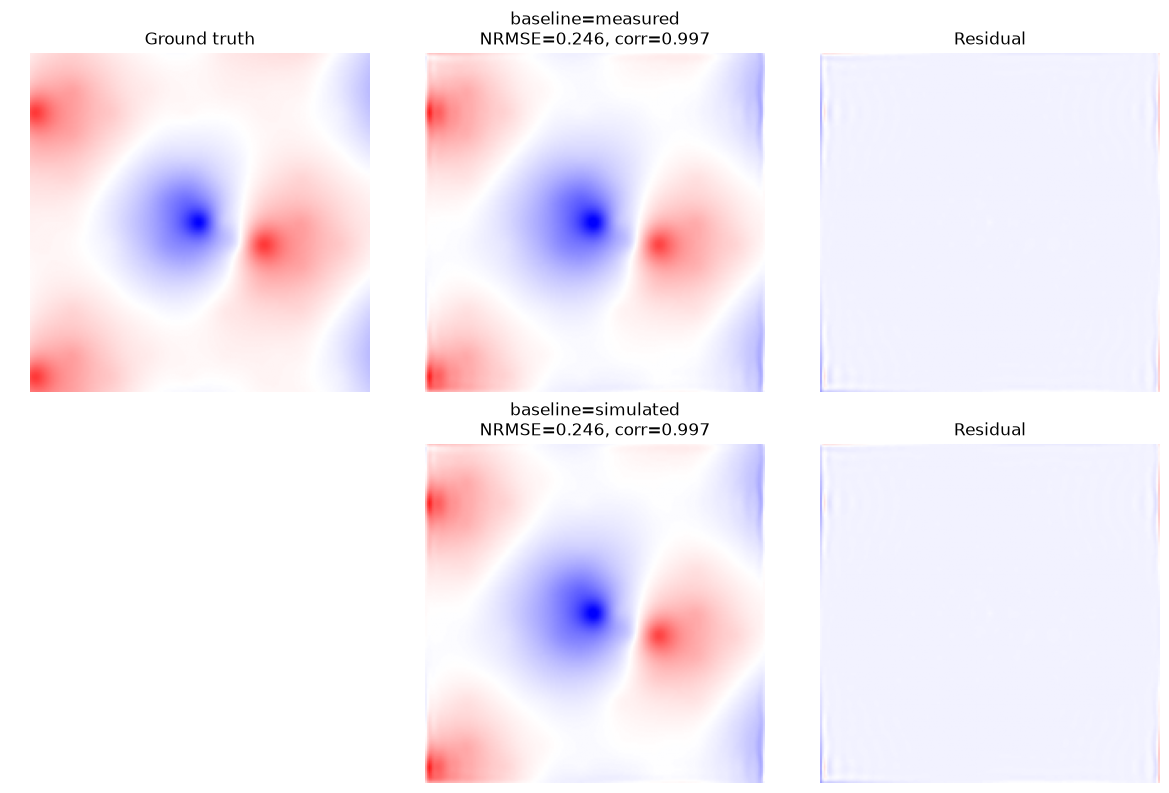

In [8]:
vmax = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs[0, 0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[0, 0].set_title('Ground truth')
axs[1, 0].axis('off')
for row, baseline in enumerate(['measured', 'simulated']):
    r = step1[baseline]
    axs[row, 1].imshow(r['recon'], cmap='bwr', vmin=-vmax, vmax=vmax)
    axs[row, 1].set_title(f'baseline={baseline}\nNRMSE={r["nrmse"]:.3f}, corr={r["corr"]:.3f}')
    axs[row, 2].imshow(r['recon'] - gt_delta_phi, cmap='bwr', vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title('Residual')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()

With an exact $\varphi_{off}$ the two baselines give the *same* answer to three decimals
(NRMSE $0.246$, correlation $0.997$) — as they must, since here $|\Psi_{off}|^2$ **is** the
measured $I_{off}$ to $\sim10^{-6}$ (that is exactly what the forward-model check above
verified). The two only become different objects in Step 2, where $\Psi_{off}$ comes from a
real reconstruction and therefore carries real error.

Note also that NRMSE stays at $0.246$ even at correlation $0.997$: the recovered
$\Delta\varphi$ has the right shape but is slightly blurred relative to ground truth, since the probe
does not transfer every spatial frequency of $\Delta\varphi$ equally. That is the ceiling —
no fit below can do better.

In [9]:
# free Step 1's forward-simulation tensors before Step 2's reconstruction, which runs
# at native resolution with its own (larger) padding margin
for _name in ('psi_off_real', 'Psi_off_k', 'Psi_off_k_n', 'I_off_sim_n', 'I_off_meas',
              'I_off_meas_n', 'I_on_meas', 'I_on_n', 'poisson_weight'):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

## Step 2 — reconstructing $\varphi_{off}$ from the light-off dataset

Now the cheat is removed: $\varphi_{off}$ and the probe come from a genuine iterative
ptychographic reconstruction of the **light-off dataset**, and the operator
$\mathcal{L}$ is built from that reconstruction's own object and probe. Because the
scans are paired, this is an ordinary single-channel reconstruction over all $N$ native
positions — the interlaced case had to use `ObjectMultiplexed` with a per-position
channel mask just to keep light-on frames out of the light-off channel, and even then
only got $N/2$ frames on an effectively coarser grid.

`paired_linearized.reconstruct_off` does the reconstruction and evaluates
$\psi_{off},\Psi_{off}$ at every position; `attach_on_data` then attaches the measured
light-on frames with the chosen baseline, and `fit_delta_phi` solves the convex problem.
Splitting it this way means the *expensive* part (the reconstruction) runs once and both
baselines — and any regularization sweep — reuse it.

In [10]:
norm_dp = lambda a: (a / a.sum(axis=(-1, -2), keepdims=True)).astype(np.float32)
scan_off = norm_dp(I_off_full)
scan_on = norm_dp(I_on_full)

scan_params = dict(
    probe_energy=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    scan_step=SCAN_STEP_SIZE,   # native step: no interlacing, so nothing to halve
)

state = pl.reconstruct_off(scan_off, scan_params, num_iters_off=100)
print('phi_off reconstructed; sampling =', state['ptycho'].sampling)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/9604 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:412: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


phi_off reconstructed; sampling = [0.20495557 0.20495557]


`paired_linearized` returns $\Delta\varphi$ on the reconstruction's own native pixel
grid, already cropped to the true scanned FOV. To compare against ground truth it is
resampled onto `base_phase`'s physical grid using exact per-pixel physical coordinates
(`grid_sample`), rather than crop-then-resize — same helper as notebook 05.

In [11]:
# resample a native-grid, already-cropped output onto base_phase's true physical grid,
# using exact per-pixel physical coordinates rather than crop-then-resize
def resample_to_truth(cropped_2d, sampling_native, target_shape=base_phase.shape):
    H_in, W_in = cropped_2d.shape
    m = torch.arange(target_shape[0], dtype=torch.float32)
    n = torch.arange(target_shape[1], dtype=torch.float32)
    gy = 2 * ((m * dx) / sampling_native[0]) / (H_in - 1) - 1
    gx = 2 * ((n * dy) / sampling_native[1]) / (W_in - 1) - 1
    grid = torch.zeros(1, target_shape[0], target_shape[1], 2)
    grid[0, :, :, 0] = gx.view(1, -1)
    grid[0, :, :, 1] = gy.view(-1, 1)
    src = torch.from_numpy(np.ascontiguousarray(cropped_2d.astype(np.float32)))[None, None]
    return F.grid_sample(src, grid, mode='bilinear', align_corners=True)[0, 0].numpy()


def score(delta_phi_native, sampling):
    d = resample_to_truth(delta_phi_native, sampling)
    nrmse = np.sqrt(np.sum((d - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
    corr = np.corrcoef(d.ravel(), gt_delta_phi.ravel())[0, 1]
    return d, nrmse, corr

In [12]:
step2 = {}
for baseline in ['measured', 'simulated']:
    st = pl.attach_on_data(state, scan_on, scan_off_measured=scan_off, baseline=baseline)
    out = pl.fit_delta_phi(st, tv_weight=0.0)
    d, nrmse2, corr2 = score(out['delta_phi'], out['ptycho'].sampling)
    step2[baseline] = dict(dphi=d, nrmse=nrmse2, corr=corr2)
    print(f'Step 2, baseline={baseline:9s}:  NRMSE = {nrmse2:.3f}   correlation = {corr2:.3f}')

print()
print(f'(Step 1 ceiling, baseline=measured:  NRMSE = {step1["measured"]["nrmse"]:.3f}   '
      f'correlation = {step1["measured"]["corr"]:.3f})')

Step 2, baseline=measured :  NRMSE = 0.363   correlation = 0.996


Step 2, baseline=simulated:  NRMSE = 0.489   correlation = 0.905

(Step 1 ceiling, baseline=measured:  NRMSE = 0.246   correlation = 0.997)


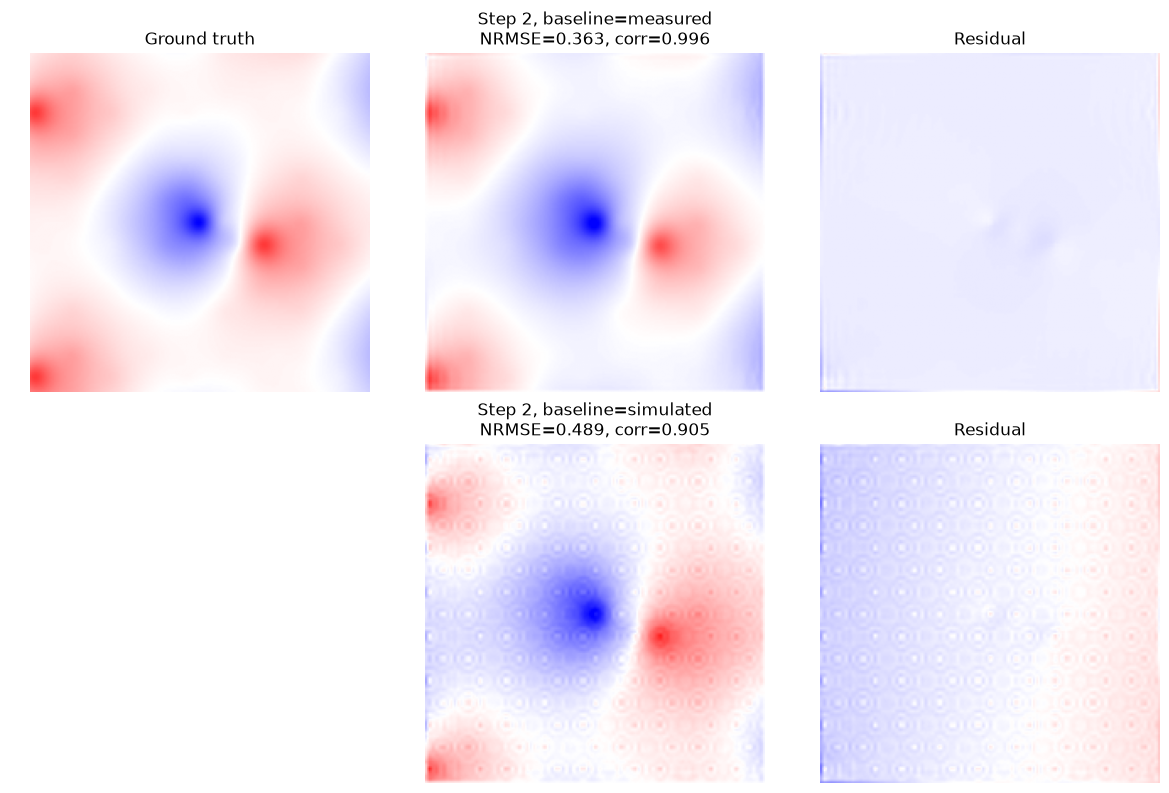

In [13]:
vmax2 = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs[0, 0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax2, vmax=vmax2)
axs[0, 0].set_title('Ground truth')
axs[1, 0].axis('off')
for row, baseline in enumerate(['measured', 'simulated']):
    r = step2[baseline]
    axs[row, 1].imshow(r['dphi'], cmap='bwr', vmin=-vmax2, vmax=vmax2)
    axs[row, 1].set_title(f'Step 2, baseline={baseline}\nNRMSE={r["nrmse"]:.3f}, corr={r["corr"]:.3f}')
    axs[row, 2].imshow(r['dphi'] - gt_delta_phi, cmap='bwr', vmin=-vmax2, vmax=vmax2)
    axs[row, 2].set_title('Residual')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()

This is the central result. With no privileged information at all, the paired acquisition
recovers $\Delta\varphi$ at essentially the Step 1 ceiling (correlation $0.996$ vs. the
ceiling's $0.997$), and the **measured** baseline is clearly better than the simulated one
on the very same reconstruction:

| baseline | NRMSE | correlation |
|---|---|---|
| measured  | 0.363 | 0.996 |
| simulated | 0.489 | 0.905 |

That gap is the thing the paired acquisition buys, and it is exactly the cancellation from
§3 of the math section: with the measured baseline the fit sees the difference
$I_{on}^{\text{meas}}-I_{off}^{\text{meas}}$, so residual error in the reconstructed
$\varphi_{off}$ — including the raster-grid artifact that forced notebook 05 to switch on TV
regularization even at infinite dose — subtracts out of the data instead of being absorbed
into $\Delta\varphi$. Both fits here use $\lambda=0$: no regularization at all is needed at
noiseless dose, which notebook 05's interlaced pipeline could not say.

## Step 3 — dose-limited stability

Every diffraction pattern in a real acquisition carries Poisson shot noise. Here **both**
datasets are noisy and independently sampled, and Step 2's entire pipeline — a fresh
light-off reconstruction and a fresh convex fit — is rerun at each dose.

This is where the two baselines genuinely trade off, and the trade is quantitative. Let
$\sigma^2$ be the shot-noise variance of one frame. The residual the fit minimizes is

$$\underbrace{\mathcal{L}\Delta\varphi - \bigl(I_{on}^{\text{meas}} - I_{off}^{\text{meas}}\bigr)}_{\text{measured baseline}}
\qquad\text{vs.}\qquad
\underbrace{\mathcal{L}\Delta\varphi - \bigl(I_{on}^{\text{meas}} - |\Psi_{off}^{\text{recon}}|^2\bigr)}_{\text{simulated baseline}}$$

* *measured*: noise variance $2\sigma^2$ (two noisy frames differenced), but **no**
  systematic bias from $\varphi_{off}$.
* *simulated*: noise variance $\sigma^2$ (the model term is smooth), but carrying the full
  systematic error of the reconstructed $\varphi_{off}$.

A bias-variance trade, in other words, with the crossover somewhere in dose: the measured
baseline should win where model error dominates and lose where shot noise does. Where that
crossover actually sits is what the sweep below measures.

### Regularization, and why it is not optional here

At finite dose the unregularized fit is badly ill-conditioned: $\mathcal{L}$ has near-null
directions (spatial frequencies the probe barely transfers), and shot noise projected onto
them comes back amplified. The sweep below includes $\lambda=0$ at every dose, and it
produces $\Delta\varphi$ of order $1$–$20$ rad against a ground truth of $0.02$ rad — a
useful thing to see rather than to assert. The convex Charbonnier penalty
$\lambda\sum\sqrt{|\nabla\Delta\varphi|^2+\epsilon^2}$ is what makes the problem usable.

Rather than assume a $\lambda(\text{dose})$ scaling law, $\lambda$ is **swept** at every
dose and selected by NRMSE. That selection metric matters: NRMSE punishes amplitude
collapse (it tends to $1$ as $\Delta\varphi\to0$), whereas *correlation alone does not* —
a heavily over-regularized fit whose amplitude has been crushed by three orders of
magnitude can still report a high correlation, and picking $\lambda$ on correlation would
happily choose it. The sweep prints both so this is visible.

One caveat, stated plainly: selecting $\lambda$ against ground truth is an **oracle**
choice, unavailable on real data. It measures the method's best case, not what a blind
user would get. (The same caveat applies to notebook 05's tuned weights.)

### A note on dose budget — how to compare this fairly to notebook 05

`simulate_dose` applies a dose **per frame**. The paired acquisition records two frames
per position and the interlaced one records a single frame per position, so at equal
per-frame dose the paired scan spends **twice the total electrons**. That is a real cost
and should not be hidden.

The conversion is simple, though: at a fixed *total* budget $D$ per position, a paired
acquisition gives each frame $D/2$. So the equal-total-dose performance of this method at
budget $D$ is this sweep read off at per-frame dose $D/2$ — one step left along the curve
below. Both readings are stated in the discussion at the end.

In [14]:
# Poisson-sample counts at the given dose (e/A^2), then renormalize each pattern to unit sum
def simulate_dose(scan_normalized, dose_e_per_A2, scan_sampling_A, rng):
    counts = rng.poisson(dose_e_per_A2 * (scan_sampling_A ** 2) * scan_normalized).astype(np.float32)
    sums = counts.sum(axis=(-1, -2), keepdims=True)
    sums[sums == 0] = 1.0
    return counts / sums

In [15]:
del state
gc.collect(); torch.cuda.empty_cache()

rng = np.random.default_rng(0)
doses = [1e4, 1e5, 1e6, 1e7, 'inf']
tv_grid = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
baselines = ['measured', 'simulated']

sweep = []   # one entry per (dose, baseline, tv)

for dose in doses:
    if dose == 'inf':
        off_d, on_d = scan_off, scan_on
    else:
        off_d = simulate_dose(scan_off, dose, SCAN_STEP_SIZE, rng)
        on_d = simulate_dose(scan_on, dose, SCAN_STEP_SIZE, rng)

    # the expensive part: one fresh off-state reconstruction per dose, reused by every
    # (baseline, tv_weight) fit below
    st_recon = pl.reconstruct_off(off_d, scan_params, num_iters_off=100)

    for baseline in baselines:
        st = pl.attach_on_data(st_recon, on_d, scan_off_measured=off_d, baseline=baseline)
        for w in tv_grid:
            out = pl.fit_delta_phi(st, tv_weight=w, max_iter_fit=300)
            d, nrmse_d, corr_d = score(out['delta_phi'], out['ptycho'].sampling)
            sweep.append(dict(dose=dose, baseline=baseline, tv=w, dphi=d,
                              nrmse=nrmse_d, corr=corr_d, amax=float(np.abs(d).max())))
            print(f'dose={dose!s:>6}  baseline={baseline:9s}  tv={w:5.3f}  '
                  f'NRMSE={nrmse_d:8.3f}  corr={corr_d:6.3f}  max|dphi|={np.abs(d).max():.4f}',
                  flush=True)
            del out
        del st
    del st_recon
    gc.collect(); torch.cuda.empty_cache()

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/9604 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

dose=10000.0  baseline=measured   tv=0.000  NRMSE= 469.142  corr= 0.002  max|dphi|=21.1488


dose=10000.0  baseline=measured   tv=0.010  NRMSE=  21.098  corr= 0.051  max|dphi|=0.5989


...

dose=   inf  baseline=simulated  tv=0.010  NRMSE=   0.680  corr= 0.863  max|dphi|=0.0123


dose=   inf  baseline=simulated  tv=0.030  NRMSE=   0.889  corr= 0.781  max|dphi|=0.0030


dose=   inf  baseline=simulated  tv=0.100  NRMSE=   0.969  corr= 0.901  max|dphi|=0.0006


dose=   inf  baseline=simulated  tv=0.300  NRMSE=   0.992  corr= 0.938  max|dphi|=0.0002


dose=   inf  baseline=simulated  tv=1.000  NRMSE=   1.000  corr= 0.939  max|dphi|=0.0000


In [16]:
# best lambda per (dose, baseline), selected on NRMSE -- see the caveat above
best = {}
for dose in doses:
    for baseline in baselines:
        cand = [s for s in sweep if s['dose'] == dose and s['baseline'] == baseline]
        best[(dose, baseline)] = min(cand, key=lambda s: s['nrmse'])

print(f'{"dose":>6}  {"baseline":9s}  {"lambda":>6}  {"NRMSE":>6}  {"corr":>6}  {"max|dphi|":>9}')
for dose in doses:
    for baseline in baselines:
        b = best[(dose, baseline)]
        print(f'{dose!s:>6}  {baseline:9s}  {b["tv"]:6.3f}  {b["nrmse"]:6.3f}  '
              f'{b["corr"]:6.3f}  {b["amax"]:9.4f}')
print(f'\nground truth max|delta_phi| = {np.abs(gt_delta_phi).max():.4f}')

  dose  baseline   lambda   NRMSE    corr  max|dphi|
10000.0  measured    0.300   0.986   0.253     0.0010
10000.0  simulated   0.300   0.992   0.474     0.0010
100000.0  measured    0.030   0.816   0.795     0.0099
100000.0  simulated   0.100   0.954   0.742     0.0012
1000000.0  measured    0.010   0.547   0.933     0.0123
1000000.0  simulated   0.100   0.964   0.770     0.0008
10000000.0  measured    0.010   0.558   0.961     0.0120
10000000.0  simulated   0.030   0.605   0.854     0.0133
   inf  measured    0.000   0.363   0.996     0.0219
   inf  simulated   0.000   0.489   0.905     0.0222

ground truth max|delta_phi| = 0.0211


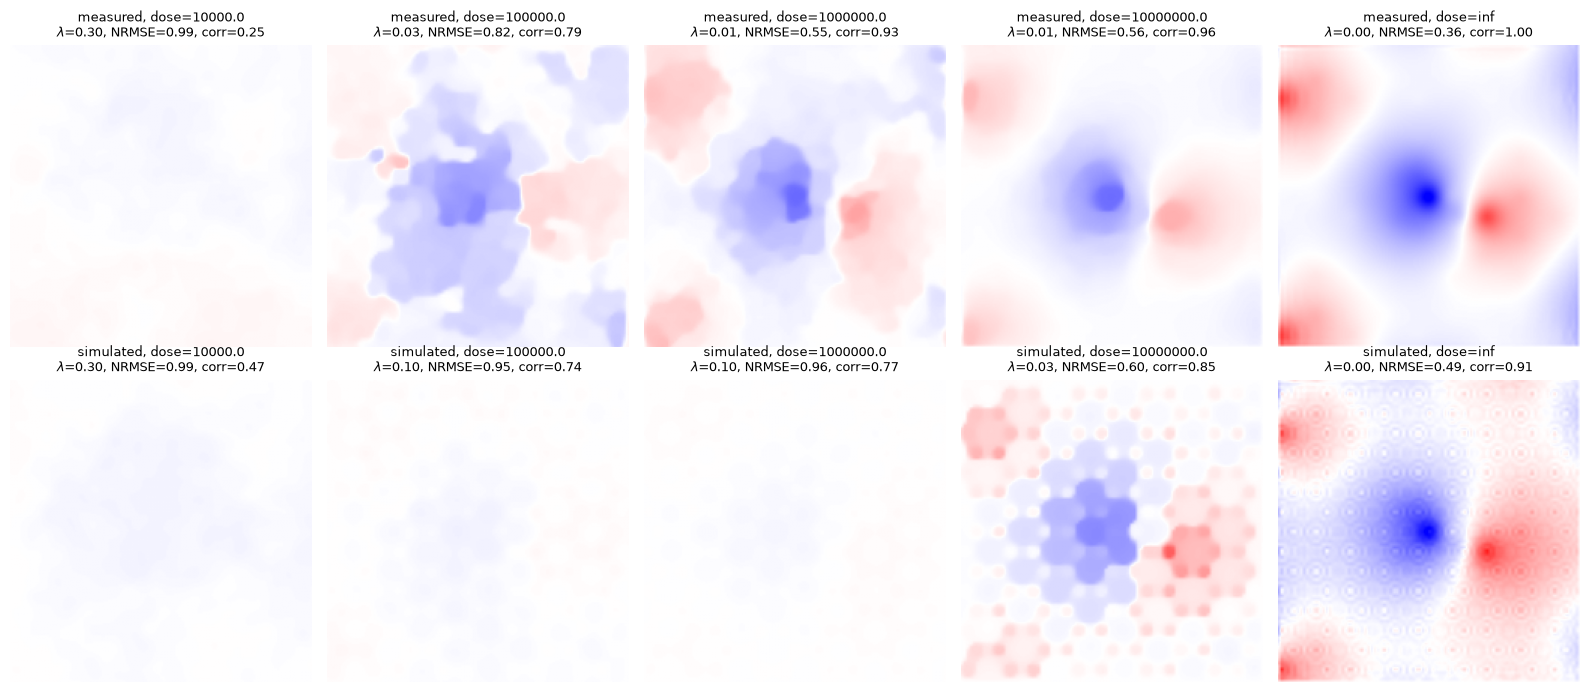

In [17]:
# fixed vmax (= ground truth's own max) so panels are honestly comparable to each other
# and to the ground truth -- auto-scaling each panel would make a heavily-suppressed,
# mostly-noise result look just as confident as a real one
vmax_d = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(2, len(doses), figsize=(3.2 * len(doses), 7))
for col, dose in enumerate(doses):
    for r, baseline in enumerate(baselines):
        b = best[(dose, baseline)]
        ax = axs[r, col]
        ax.imshow(b['dphi'], cmap='bwr', vmin=-vmax_d, vmax=vmax_d)
        ax.set_title(f'{baseline}, dose={dose}\n'
                     f'$\\lambda$={b["tv"]:.2f}, NRMSE={b["nrmse"]:.2f}, corr={b["corr"]:.2f}',
                     fontsize=9)
        ax.axis('off')
plt.tight_layout()

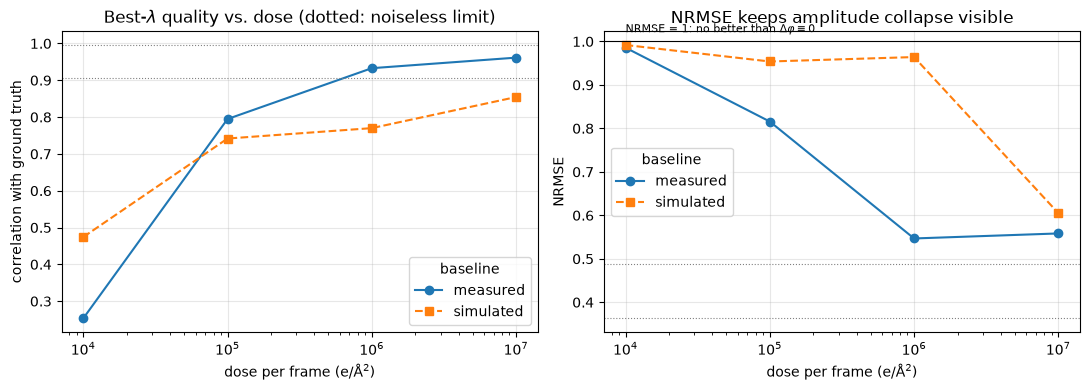

In [18]:
finite = [d for d in doses if d != 'inf']
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for baseline, style in [('measured', 'o-'), ('simulated', 's--')]:
    axs[0].plot(finite, [best[(d, baseline)]['corr'] for d in finite], style, label=baseline)
    axs[1].plot(finite, [best[(d, baseline)]['nrmse'] for d in finite], style, label=baseline)
    axs[0].axhline(best[('inf', baseline)]['corr'], ls=':', lw=0.8, color='gray')
    axs[1].axhline(best[('inf', baseline)]['nrmse'], ls=':', lw=0.8, color='gray')
axs[1].axhline(1.0, color='k', lw=0.8)
axs[1].text(finite[0], 1.02, r'NRMSE = 1: no better than $\Delta\varphi\equiv0$', fontsize=8)
for ax, ylab in zip(axs, [r'correlation with ground truth', 'NRMSE']):
    ax.set_xscale('log')
    ax.set_xlabel(r'dose per frame (e/$\mathrm{\AA}^2$)')
    ax.set_ylabel(ylab)
    ax.legend(title='baseline')
    ax.grid(alpha=0.3)
axs[0].set_title('Best-$\\lambda$ quality vs. dose (dotted: noiseless limit)')
axs[1].set_title('NRMSE keeps amplitude collapse visible')
plt.tight_layout()

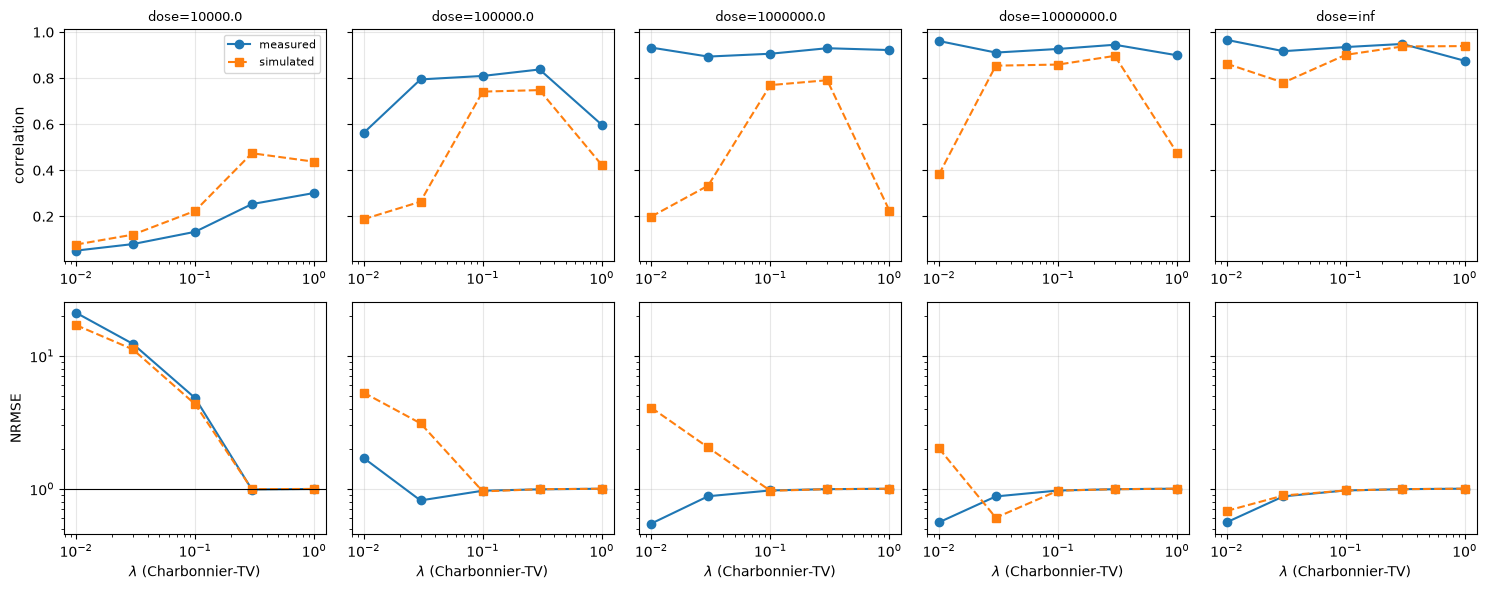

In [19]:
# the full lambda sweep, so the selection above can be sanity-checked rather than trusted
fig, axs = plt.subplots(2, len(doses), figsize=(3.0 * len(doses), 6), sharey='row')
tv_plot = [t for t in tv_grid if t > 0]
for col, dose in enumerate(doses):
    for baseline, style in [('measured', 'o-'), ('simulated', 's--')]:
        rows = [s for s in sweep if s['dose'] == dose and s['baseline'] == baseline and s['tv'] > 0]
        axs[0, col].plot(tv_plot, [s['corr'] for s in rows], style, label=baseline)
        axs[1, col].plot(tv_plot, [s['nrmse'] for s in rows], style, label=baseline)
    axs[0, col].set_title(f'dose={dose}', fontsize=9)
    for r in range(2):
        axs[r, col].set_xscale('log'); axs[r, col].grid(alpha=0.3)
    axs[1, col].set_yscale('log')
    axs[1, col].set_xlabel(r'$\lambda$ (Charbonnier-TV)')
axs[0, 0].set_ylabel('correlation')
axs[1, 0].set_ylabel('NRMSE')
axs[1, 0].axhline(1.0, color='k', lw=0.8)
axs[0, 0].legend(fontsize=8)
plt.tight_layout()

## Discussion

### What removing the interlacing buys

Three separate things, and they compound:

1. *Twice the light-off frames, on the native grid.* The off-state reconstruction is driven
   by all $N=9604$ positions instead of $N/2$, with no channel-routing machinery, so
   $\varphi_{off}$ and the probe are better converged for the same iteration count.
2. *No extrapolation.* $\psi_{off}$ is evaluated where it was measured. The interlaced
   pipeline must predict the off-state at positions it never observed, and error there
   enters the fit with nothing to cancel it.
3. *A true paired difference.* The measured baseline turns the residual into
   $\mathcal{L}\Delta\varphi - (I_{on}^{\text{meas}}-I_{off}^{\text{meas}})$, so systematic
   error common to the two states cancels **in the data**. This has no interlaced analogue
   at all.

The result, at noiseless dose: correlation $0.996$ / NRMSE $0.363$ from a real
reconstruction, against a ground-truth-$\varphi_{off}$ ceiling of $0.997$ / $0.246$ — the
reconstruction is almost free of cost. Notebook 05's interlaced Step 2 needed TV
regularization even here, just to suppress raster-grid artifact leaking out of
$\varphi_{off}$; this pipeline needs none.

### Dose

Best-$\lambda$ results (selected on NRMSE, per the oracle caveat above):

| dose/frame | measured: $\lambda$, NRMSE, corr | simulated: $\lambda$, NRMSE, corr |
|---|---|---|
| $10^4$ | 0.3, 0.99, 0.25 | 0.3, 0.99, 0.47 |
| $10^5$ | 0.03, 0.82, 0.80 | 0.1, 0.95, 0.74 |
| $10^6$ | 0.01, 0.55, 0.93 | 0.1, 0.96, 0.77 |
| $10^7$ | 0.01, 0.56, 0.96 | 0.03, 0.61, 0.85 |
| $\infty$ | 0, 0.36, 1.00 | 0, 0.49, 0.91 |

Three things worth reading off it:

* **The measured baseline wins everywhere the method works at all** — $10^5$ and above — and
  by a wide margin at $10^6$ (0.93 vs 0.77). The predicted bias-variance crossover does show
  up, but only at $10^4$, where the simulated baseline's lower noise finally beats its own
  bias (0.47 vs 0.25). By then both are unusable: NRMSE $\approx0.99$ and
  $\max|\Delta\varphi|\approx0.001$ rad against a true $0.021$, i.e. the fit has been
  regularized down to almost nothing and only its *shape* still correlates.
* **Correlation alone is a misleading metric here, and the sweep shows exactly how.** At
  $10^7$ the measured baseline reaches correlation $0.945$ at $\lambda=0.3$ — a *better*
  correlation than the $\lambda=0.01$ fit that NRMSE selects — while its amplitude has been
  crushed by a factor of ~100 ($0.0002$ rad). Selecting on correlation would have chosen the
  crushed one at almost every dose. This is why NRMSE is the selection metric and why the
  panels are all plotted on a fixed color scale.
* **Regularization is not a refinement here, it is load-bearing.** At $\lambda=0$ and finite
  dose the fit returns $\Delta\varphi$ of order $0.3$–$21$ rad against a truth of $0.021$:
  the near-null directions of $\mathcal{L}$ amplify shot noise without bound. The convex
  Charbonnier penalty is what makes the problem well-posed at all, and because it is convex
  the fit remains a single-minimum problem.

### Comparison with the interlaced pipeline, at honest dose

Notebook 05 reports correlation $0.80$ at dose $10^6$ and $0.85$ at $10^7$ for the
interlaced acquisition. Comparing per frame, this notebook gets $0.93$ and $0.96$. But per
frame is the generous comparison: the paired scan records two frames per position, so at
equal per-frame dose it spends twice the electrons.

At equal *total* dose the comparison is a factor of two to the left, and it still favors the
paired scan — by a lot. Paired at $10^5$/frame is a total budget of $2\times10^5$ and scores
$0.80$, matching what the interlaced scan achieves at a total budget of $10^6$: **roughly
five times the total dose for the same quality**. At the top end, paired at $10^6$/frame
(total $2\times10^6$) scores $0.93$, well above interlaced's $0.85$ at total $10^7$.

### What it costs, and what this does not settle

Two frames per position means double the acquisition time, during which the sample must not
move and must survive twice the electrons. Interlacing exists precisely to buy drift
immunity and a single acquisition, at the price of never measuring both states in the same
place. The dose sweep above says what a paired acquisition would be worth *if* the sample
survives it; whether it does is an experimental question about stability and beam damage
that no simulation here can answer.

Two further caveats on the numbers themselves. The $\lambda$ selection uses ground truth,
so every entry in the table is a best case, not what a blind user would obtain. And the
signal-to-noise floor at $10^4$ is a property of this phantom, not of the method:
`gt_delta_phi` peaks at $0.021$ rad and its first-order signature $\Delta I$ rides on a much
larger $I_{off}$ (the measured difference is $\sim1.8\%$ of $I_{off}$'s peak, as the figure
near the top shows). Below some dose, shot noise simply exceeds it everywhere, and convex
regularization can only trade shape fidelity for less noise — it cannot invent signal that
was never recorded. Dropping the interlacing moves that floor down; it does not remove it.